# Task 1 - Data Loading & Exploration

### Import Necessary Libraries

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.feature_selection import VarianceThreshold

## 1.1. Load the Dataset

In [19]:
data = load_breast_cancer()

# Features
X = pd.DataFrame(data.data, columns=data.feature_names)

# Target variable
y = pd.Series(data.target, name='target')

# Add the target variable to the DataFrame for easier analysis
df = pd.concat([X, y], axis=1)
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


## 1.2. Data Overview

### Dataset Shape

In [20]:
print(f"Number of rows: {df.shape[0]} samples")
print(f"Number of columns: {df.shape[1]-1} variables + 1 target")

Number of rows: 569 samples
Number of columns: 30 variables + 1 target


### Data Types

In [21]:
print(f"Data types:\n{df.dtypes.value_counts()}")

Data types:
float64    30
int64       1
Name: count, dtype: int64


All features are decimal (float) except the target variable which is a binary (integer) variable.

### Missing Values

In [22]:
print(f"Total missing values: {df.isna().sum().sum()}")

Total missing values: 0


### Summary statistics

In [23]:
df.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


## 1.3. Class Distribution

### Counts Per Class

In [24]:
class_counts = df['target'].value_counts()
class_percentages = df['target'].value_counts(normalize=True)*100

class_dict = {0: 'Malignant', 1: 'Benign'}

balance_df = pd.DataFrame({
    'Count': class_counts,
    'Percentage (%)': class_percentages.round(2)
})
balance_df.index = [class_dict[i] + f" ({i})" for i in balance_df.index]
print(balance_df)

               Count  Percentage (%)
Benign (1)       357           62.74
Malignant (0)    212           37.26


The dataset is slightly imbalanced, with more benign cases (1) than malignant ones (0).

### Histograms

Matrix Layout: rows for base features, columns for mean/error/worst.

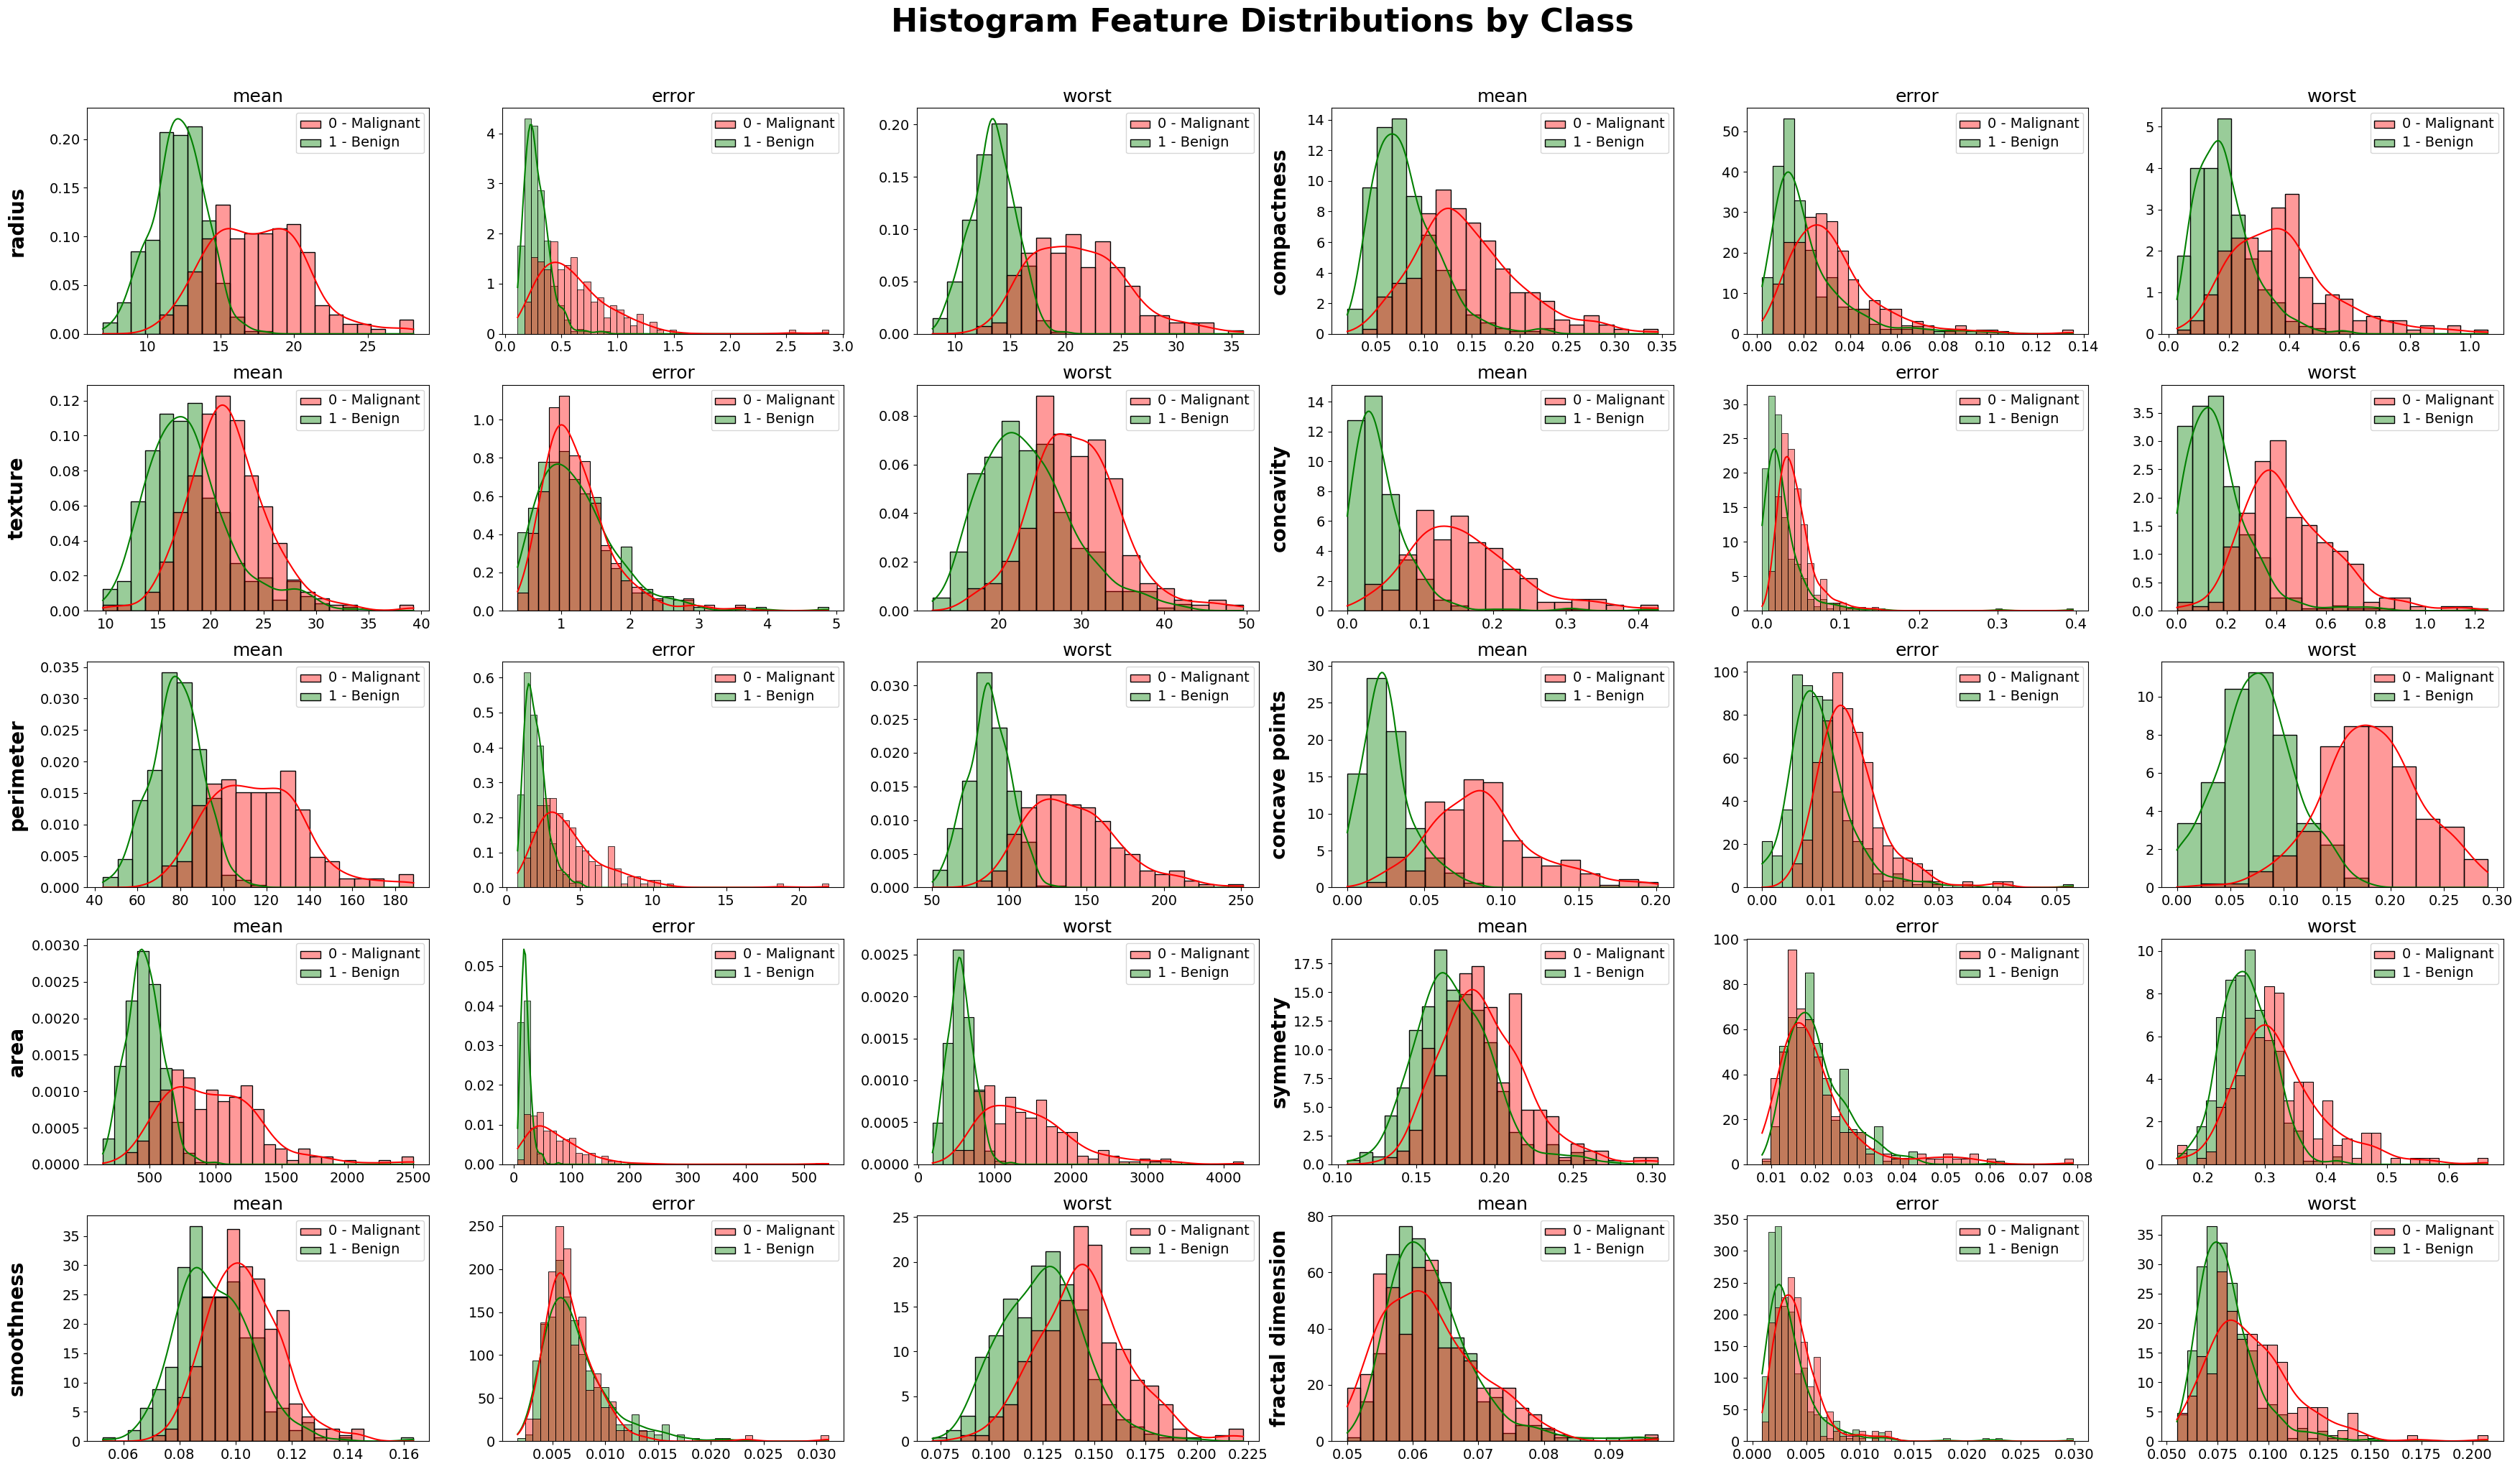

In [59]:
fig, axes = plt.subplots(5, 6, figsize=(35, 20))

cat_y = y.map({0: '0 - Malignant', 1: '1 - Benign'})
base_features = [col.replace('mean ', '') for col in X.columns if col.startswith('mean ')] # detect base feature names by removing 'mean ' prefix

# Plot histograms in a matrix layout: rows for base features, columns for mean/error/worst
for i, base_name in enumerate(base_features):

    row = i % 5  # Row index (0 to 4)
    col_offset = (i//5) * 3  # Column offset for each set of 3 features

    col_mean = f"mean {base_name}"
    col_error = f"{base_name} error"
    col_worst = f"worst {base_name}"

    cols_to_plot = [col_mean, col_error, col_worst]

    for j, col_name in enumerate(cols_to_plot):
        col = col_offset + j  # Column index for the current feature
        sns.histplot(
            data=X,
            x=col_name,
            hue=cat_y,
            stat='density', # Show density instead of count
            common_norm=False, # Normalize each class separately.
            ax=axes[row, col],
            kde=True, # Add KDE curve
            palette={'0 - Malignant': 'red', '1 - Benign': 'green'},
            alpha=0.4
        )

        if j == 0:
            axes[row, col].set_title("mean", fontsize=18)
        elif j == 1:
            axes[row, col].set_title("error", fontsize=18)
        elif j == 2:
            axes[row, col].set_title("worst", fontsize=18)

        axes[row, col].tick_params(labelsize=14)  
        axes[row, col].set_xlabel('')
        axes[row, col].set_ylabel(base_name if j == 0 else '', fontsize=20, fontweight='bold') # just label y-axis for the first column
        axes[row, col].get_legend().set_title(None)

        for text in axes[row, col].get_legend().get_texts():
            text.set_fontsize(14)  # Set legend text size

fig.suptitle('Histogram Feature Distributions by Class', fontsize=32, fontweight='bold', y=1.02)
fig.align_ylabels()
fig.tight_layout()
plt.show(fig)

fig.savefig('../figures/exploration/histogram_features.png', dpi=300, bbox_inches='tight')

**Observations:**
1. Several attributes show visual distinction between malignant (red) and benign (green) tumors. `radius`, `perimeter`, `area`, and `concave points` (especially in their *mean* and *worst* metrics), the benign class is clustered at lower values while the malignant class shows higher values.

2. There are features where the red and green distributions overlap almost entirely, what makes them not strong differentiators for the target variable. This overlap is particularly noticeable in `fractal dimension` (*mean* and *error*), `smoothness` (*error*), and `symmetry` (*error*).

3. The **benign class (green)** tends to have narrower distributions with sharper peaks, indicating lower variance. The **malignant class (red)** displays greater dispersion, and many of its distributions are right-skewed (featuring long tails). This pattern is evident across almost all the *error* metrics (e.g., `area error`, `perimeter error`).


### Boxplots

Matrix Layout: rows for base features, columns for mean/error/worst.

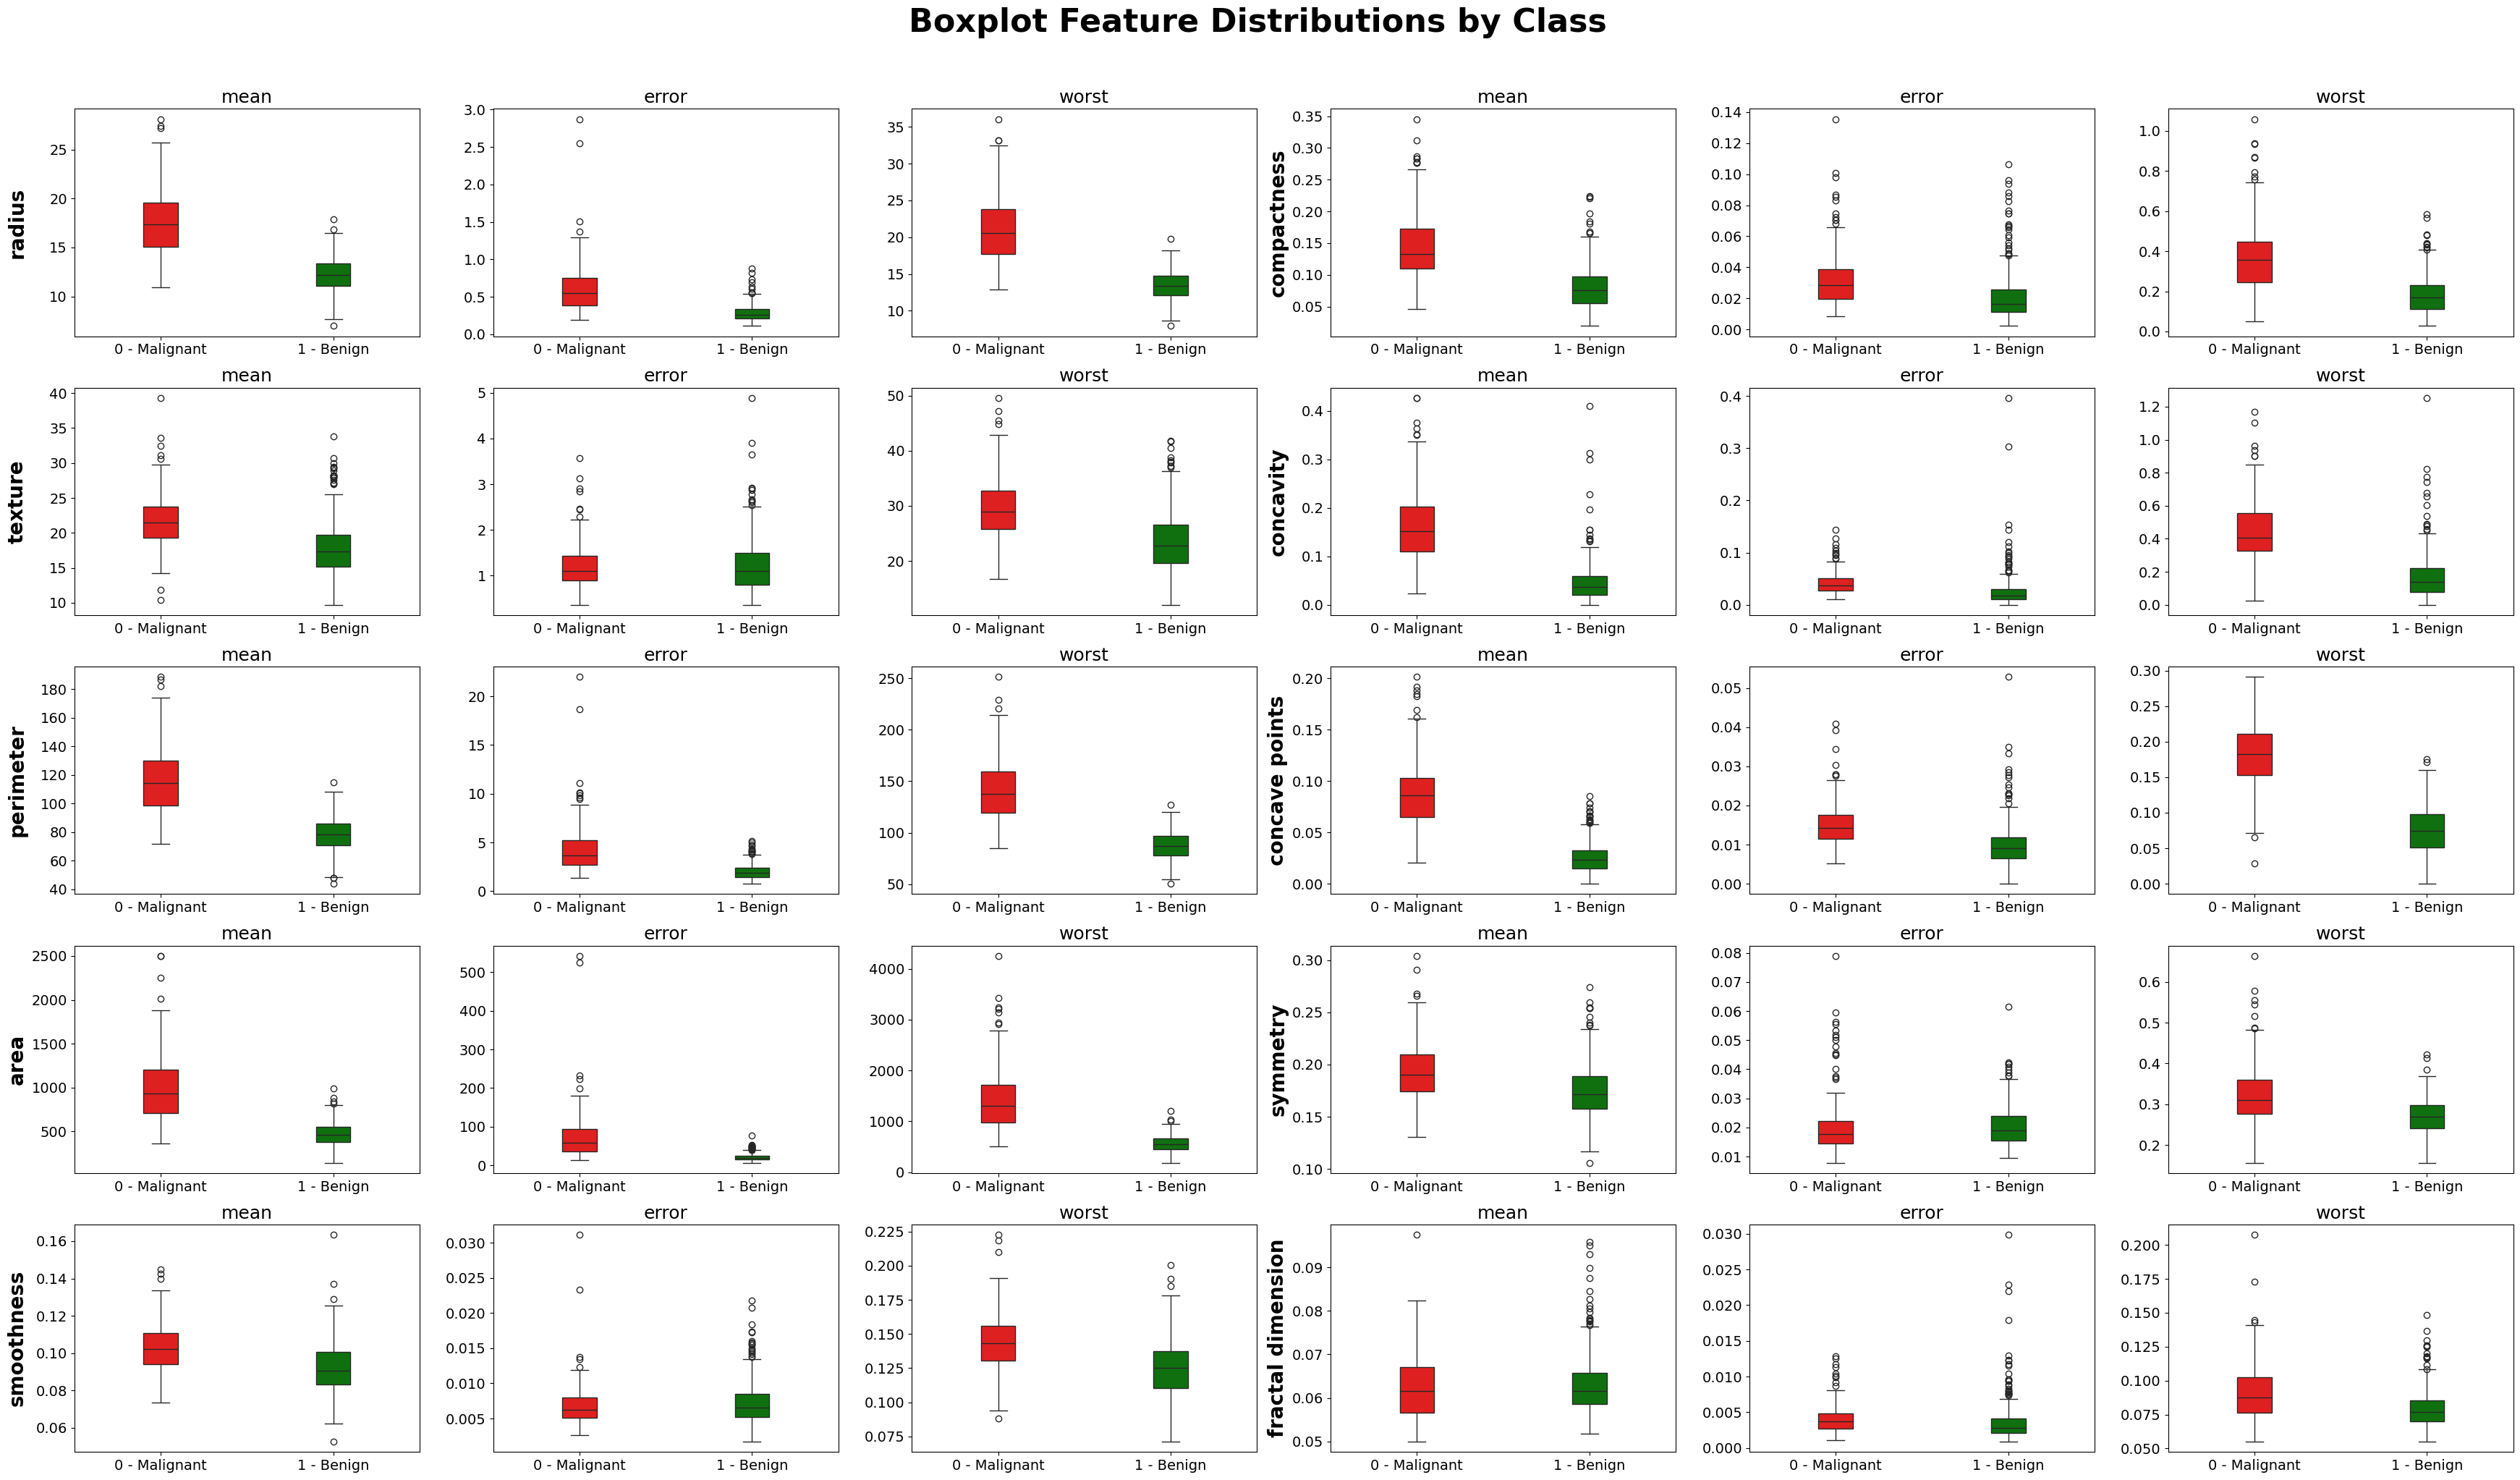

In [60]:
fig, axes = plt.subplots(5, 6, figsize=(35, 20))

cat_y = y.map({0: '0 - Malignant', 1: '1 - Benign'})
base_features = [col.replace('mean ', '') for col in X.columns if col.startswith('mean ')] # detect base feature names by removing 'mean ' prefix

# Plot boxplots in a matrix layout: rows for base features, columns for mean/error/worst
for i, base_name in enumerate(base_features):

    row = i % 5  # Row index (0 to 4)
    col_offset = (i//5) * 3  # Column offset for each set of 3 features

    col_mean = f"mean {base_name}"
    col_error = f"{base_name} error"
    col_worst = f"worst {base_name}"

    cols_to_plot = [col_mean, col_error, col_worst]

    for j, col_name in enumerate(cols_to_plot):
        col = col_offset + j  # Column index for the current feature
        sns.boxplot(
            data=X,
            x=cat_y,
            hue=cat_y,
            palette={'0 - Malignant': 'red', '1 - Benign': 'green'},
            y = col_name,
            width=0.2,
            ax=axes[row, col],
            log_scale=False
        )


        if j == 0:
            axes[row, col].set_title("mean", fontsize=18)
        elif j == 1:
            axes[row, col].set_title("error", fontsize=18)
        elif j == 2:
            axes[row, col].set_title("worst", fontsize=18)

        axes[row, col].tick_params(labelsize=14)
        axes[row, col].set_xlabel('')
        axes[row, col].set_ylabel(base_name if j == 0 else '', fontsize=20, fontweight='bold') # just label y-axis for the first column

fig.suptitle('Boxplot Feature Distributions by Class', fontsize=32, fontweight='bold', y=1.02)
fig.align_ylabels()
fig.tight_layout()
plt.show(fig)

fig.savefig('../figures/exploration/boxplot_features.png', dpi=300, bbox_inches='tight')


**Observations:**
1. **Medians and Interquartile Range (IQR):** Boxplots show that malignant tumors present higher median values across *size* and *severity* metrics (`mean radius`, `mean perimeter`, `mean area` and `mean concavity`). The interquartile ranges, i.e., the boxes themselves representing the middle 50% of the data, are also generally wider for the malignant class, confirming the higher variance and structural inconsistency.

2. **Right-skewed:** Boxplots strongly emphasizes the right-skewed nature of the malignant class. Lots of features display extremely long upper whiskers and numerous high-value outliers. This reflects the uncontrolled growth typical of cancerous cells in comparison with the benign class, which remains much more tightly clustered at lower values.

3. **Confirmation of Separability:** Almmost all *mean* and *worst* feature metrics such as `worst perimeter`, `worst area`, or `worst concave points` present boxes that separate completely, meaning that they are strong discriminators. Almost all *error* feature metrics such as `smoothness error`,`symmetry error`, or even the `mean fractal dimension` show overlapping boxes and medians that are similar, confirming they offer low predictive power on their own.

4. **Scale Disparity:** There is a massive difference in magnitudes across different features. This evidence justifies the need to apply `StandardScaler` in the preprocessing stage to prevent features with large absolute valures from dominating distance-based algorithms.


### Correlation Heatmap

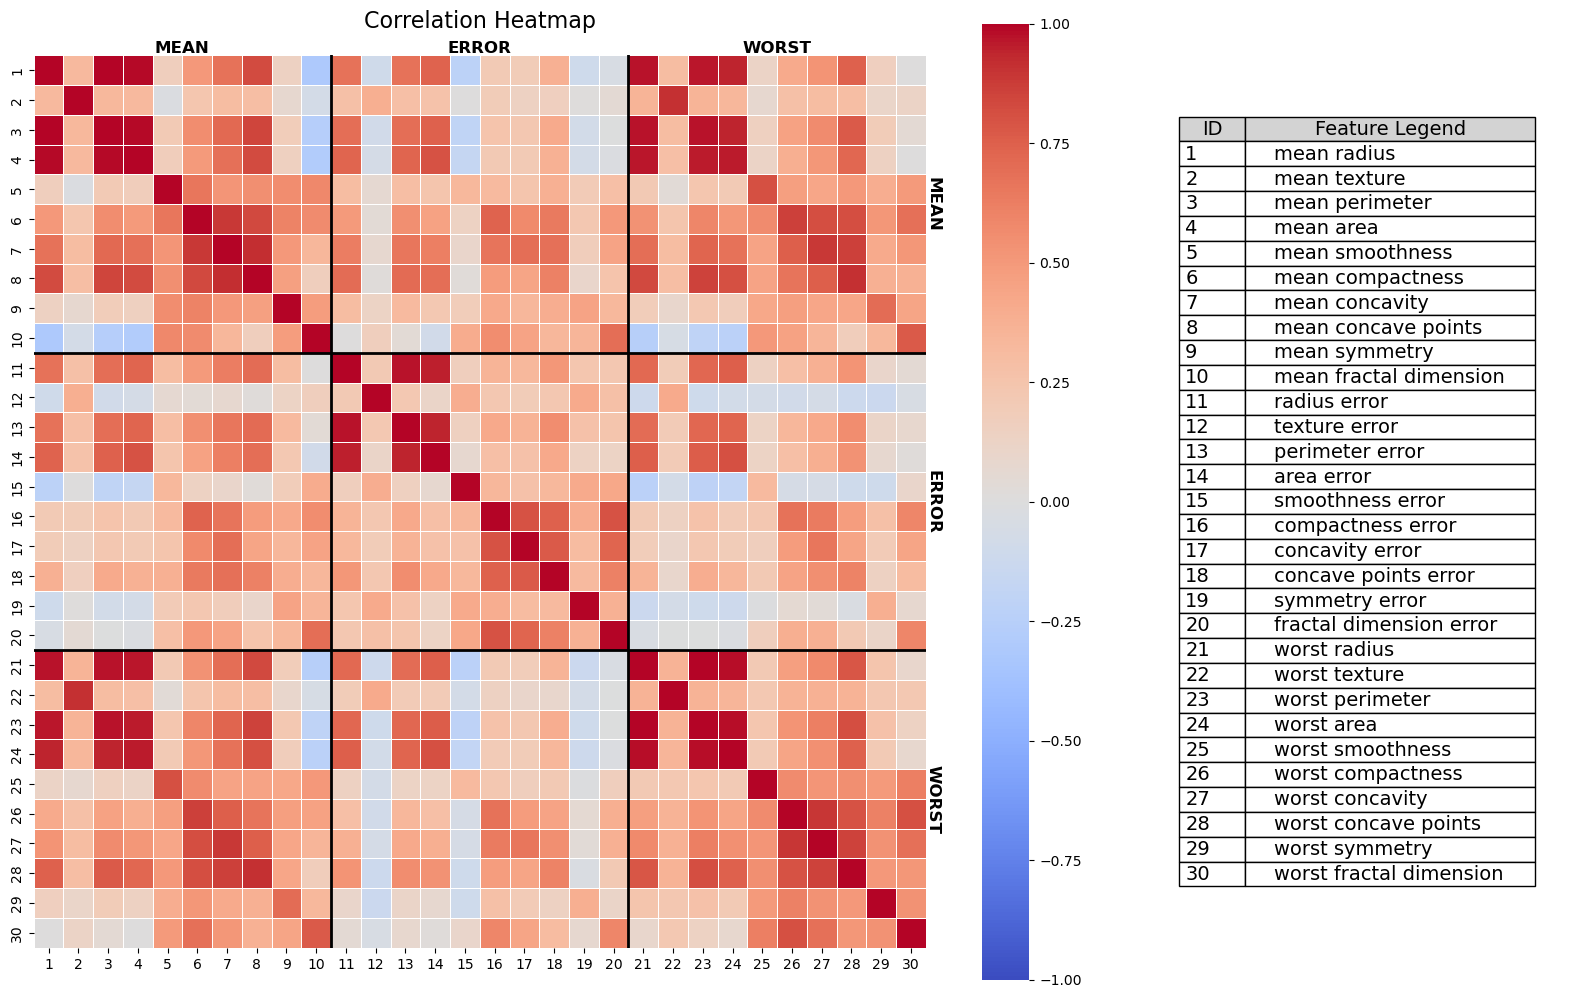

In [27]:
corr_matrix = X.corr()
dict_features = {i+1: name for i, name in enumerate(corr_matrix.columns)}

fig, (ax_heatmap, ax_legend) = plt.subplots(1, 2, figsize=(16, 10), gridspec_kw={'width_ratios': [2.5, 1]})

sns.heatmap(
    corr_matrix,
    cmap='coolwarm',          # Red for positive, blue for negative correlations
    vmax=1.0, vmin=-1.0,      # Fix the range of the color scale
    center=0,                 # The white will be exactly at 0 (no correlation)
    annot=False,              # False to not show the 900 numbers
    square=True,              # Makes each cell square
    linewidths=0.5,           # Small line of separation between cells
    xticklabels=list(dict_features.keys()),
    yticklabels=list(dict_features.keys()),
    ax = ax_heatmap
)
line_style = {'color': 'black', 'linewidth': 2}
ax_heatmap.axvline(x=10, **line_style)  # Vertical line after the 10th feature
ax_heatmap.axvline(x=20, **line_style)  # Vertical line after the 20th feature
ax_heatmap.axhline(y=10, **line_style)  # Horizontal line after the 10th feature
ax_heatmap.axhline(y=20, **line_style)  # Horizontal line after the 20th feature

text_style_v = {'ha': 'center', 'va': 'bottom', 'fontweight': 'bold', 'fontsize': 12}
ax_heatmap.text(5, 0, 'MEAN', **text_style_v)
ax_heatmap.text(15, 0, 'ERROR', **text_style_v)
ax_heatmap.text(25, 0, 'WORST', **text_style_v)

text_style_h = {'rotation': 270, 'va': 'center', 'ha': 'left', 'fontweight': 'bold', 'fontsize': 12}
ax_heatmap.text(30, 5, 'MEAN', **text_style_h)
ax_heatmap.text(30, 15, 'ERROR', **text_style_h)
ax_heatmap.text(30, 25, 'WORST', **text_style_h)

ax_heatmap.set_title('Correlation Heatmap', fontsize=16, pad=20)
ax_legend.axis('off')  # Hide the axis for the legend


legend = ax_legend.table(
    cellText=[[key, value] for key, value in dict_features.items()],
    colLabels=["ID", "Feature Legend"],
    loc='center',
    cellLoc='left',
    colColours=["lightgrey", "lightgrey"],
    colWidths=[0.15, 0.65]
)
legend.auto_set_font_size(False)
legend.set_fontsize(14)
legend.scale(1, 1.2)  # Scale the legend for better readability

plt.tight_layout()
plt.show(fig)

fig.savefig('../figures/exploration/correlation_heatmap.png', dpi=300, bbox_inches='tight')


**Discussion of top correlatied features:**
1. **Size Metrics:** The strongest correlations exist between `radius`, `perimeter`, and `area` across all three of their metrics (*mean*, *error*, and *worst*). This makes sense, as perimeter and area are functions of the radius.

2. **Shape Severity:** Another cluster of high positive correlation is found between `compactness`, `concavity`, and `concave points`. This makes sense because a cell nucleus with a highly irregular, concave contour will have more concave points and a higher compactness score.

3. **Mean vs Worst Redundancy:** There is a strong correlation between the *mean* values and the *worst* values for almost every single attribute.


# Task 2 - Preprocessing & Feature Analysis

## 2.1. Split

In [28]:
X_train_raw, X_test_raw, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

print(f"Proportion of classes in y_train:\n{y_train.value_counts(normalize=True).round(3)*100}%")
print(f"Training set size: {X_train_raw.shape[0]} samples")

print(f"\nProportion of classes in y_test:\n{y_test.value_counts(normalize=True).round(3)*100}%")
print(f"Testing set size: {X_test_raw.shape[0]} samples")

Proportion of classes in y_train:
target
1    62.6
0    37.4
Name: proportion, dtype: float64%
Training set size: 455 samples

Proportion of classes in y_test:
target
1    63.2
0    36.8
Name: proportion, dtype: float64%
Testing set size: 114 samples


## 2.2 Scaling

In [29]:
scaler_standard = StandardScaler()
X_train_scaled = scaler_standard.fit_transform(X_train_raw)
X_test_scaled = scaler_standard.transform(X_test_raw)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns, index=X_train_raw.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns, index=X_test_raw.index)

print(f"Mean of first 5 features (should be close to 0):\n{X_train_scaled.iloc[:, :5].mean().round(3)}")
print(f"Mean of the mean of all features: {X_train_scaled.mean().mean().round(3)}")
print(f"\nStandard deviation of first 5 features (should be close to 1):\n{X_train_scaled.iloc[:, :5].std().round(3)}")
print(f"Mean of standard deviations of all features: {X_train_scaled.std().mean().round(3)}")

Mean of first 5 features (should be close to 0):
mean radius       -0.0
mean texture       0.0
mean perimeter    -0.0
mean area         -0.0
mean smoothness    0.0
dtype: float64
Mean of the mean of all features: 0.0

Standard deviation of first 5 features (should be close to 1):
mean radius        1.001
mean texture       1.001
mean perimeter     1.001
mean area          1.001
mean smoothness    1.001
dtype: float64
Mean of standard deviations of all features: 1.001


## 2.3. Feature Analysis

### Variance-Based Filtering

We must apply the zero-variance filtering to MinMaxScaled features, not to the StandardScaled features.

`MinMaxScaler` scales features to a defined range [0, 1] preserving the original distribution shape, whereas `StandardScaler` applies Z-score normalization ($\mu=0$, $\sigma=1$).

In [30]:
scaler_minmax = MinMaxScaler()
X_train_minmax = scaler_minmax.fit_transform(X_train_raw)
X_train_minmax = pd.DataFrame(X_train_minmax, columns=X.columns, index=X_train_raw.index)

threshold_nzv = 0.01
selector_nzv = VarianceThreshold(threshold=threshold_nzv)
selector_nzv.fit(X_train_minmax)
to_drop_nzv = list(X_train_raw.columns[~selector_nzv.get_support()])

print(f"Near-zero variance threshold: {threshold_nzv}")
print(f"\n{len(to_drop_nzv)} near-zero variance features:")
for feature in to_drop_nzv:
    print(f"- {feature}")


Near-zero variance threshold: 0.01

5 near-zero variance features:
- radius error
- perimeter error
- area error
- concavity error
- fractal dimension error


A conservative variance threshold of 0.01 is applied after a temporary MinMax scaling, which is equivalent to a 10% deviation from the mean. Features below thiss threshold are considered to have near-zero variance and are removed. This approach safely removes constant features and measurement noise, while preserving the biological fluctuations that are relevant for predicting malignancy.

### Correlation-Based Filtering

In [31]:
corr_matrix_train = X_train_scaled.drop(columns=to_drop_nzv).corr().abs()

# Create an upper triangle mask to avoid duplicate pairs and self-correlation
corr_matrix_upper = corr_matrix_train.where(
    np.triu(                                # np.triu returns the upper triangle of an array, and we use it to create a mask that keeps only the upper triangle of the correlation matrix
        np.ones(corr_matrix_train.shape),   # Create a matrix of ones with the same shape as the correlation matrix
        k=1                                 # keep the diagonal (self-correlation) as False, and the upper triangle as True
    ).astype(bool)
)

threshold = 0.85
to_drop_corr = [column for column in corr_matrix_upper.columns if any(corr_matrix_upper[column] > threshold)] # if any correlation above the threshold, mark the column for dropping

print(f"Correlation threshold: {threshold}")
print(f"\n{len(to_drop_corr)} redundant features:")
for feature in to_drop_corr:
    print(f"- {feature}")

Correlation threshold: 0.85

11 redundant features:
- mean perimeter
- mean area
- mean concavity
- mean concave points
- worst radius
- worst texture
- worst perimeter
- worst area
- worst compactness
- worst concavity
- worst concave points


To combat multicollinearity, a strict Pearson correlation threshold of 0.85 is implemented. Given that many features in this dataset are direct mathematical derivations (e.g., radius, permieter, and area), this threshold effectively purges redundant gemoetric data, reducing dimensionality and overfitting risk without sacrificing indepenent predictive power.

### Final Preprocessed Dataset

In [32]:
to_drop = list(set(to_drop_nzv + to_drop_corr))
X_train = X_train_scaled.drop(columns=to_drop)
X_test = X_test_scaled.drop(columns=to_drop)

print(f"{len(to_drop)} features dropped in total.")
print(f"X_train ready for the model: {X_train.shape[1]} columns")
print(f"X_test ready for the model: {X_test.shape[1]} columns")

16 features dropped in total.
X_train ready for the model: 14 columns
X_test ready for the model: 14 columns


In [34]:
X.to_csv('../data/1_raw/X.csv', index=True)
y.to_csv('../data/1_raw/y.csv', index=True)

X_train.to_csv('../data/2_processed/X_train.csv', index=True)
y_train.to_csv('../data/2_processed/y_train.csv', index=True)
X_test.to_csv('../data/2_processed/X_test.csv', index=True)
y_test.to_csv('../data/2_processed/y_test.csv', index=True)

print("Processed datasets saved.")

Processed datasets saved.
